### Actividad en equipo sesión 10
* Mariana Buentello
* Mario Sánchez

**Contexto**  
Un técnico diagnostica aires acondicionados. Dos averías independientes pueden presentarse en una unidad: una fuga de refrigerante (ocurre en el 10% de las unidades) y un fallo del compresor (ocurre, de forma independiente, en el 5 %). El síntoma observable es que el equipo no enfríe. La probabilidad de que no enfríe depende de qué averías estén presentes: sin ninguna avería, casi siempre enfría (no enfría solo el 2 %); si solo falla el compresor, no enfría el 85 %; si solo hay fuga, no enfría el 75 %; y si están ambas, no enfría el 95 %.  
Variables (binarias)  
* F — Fuga de refrigerante: 0=no, 1=sí  
* C — Fallo del compresor: 0=no, 1=sí  
* N — No enfría: 0=enfría, 1=no enfría

1. Deduce la estructura del grafo a partir del contexto y arma la red en pgmpy con las probabilidades del texto.  

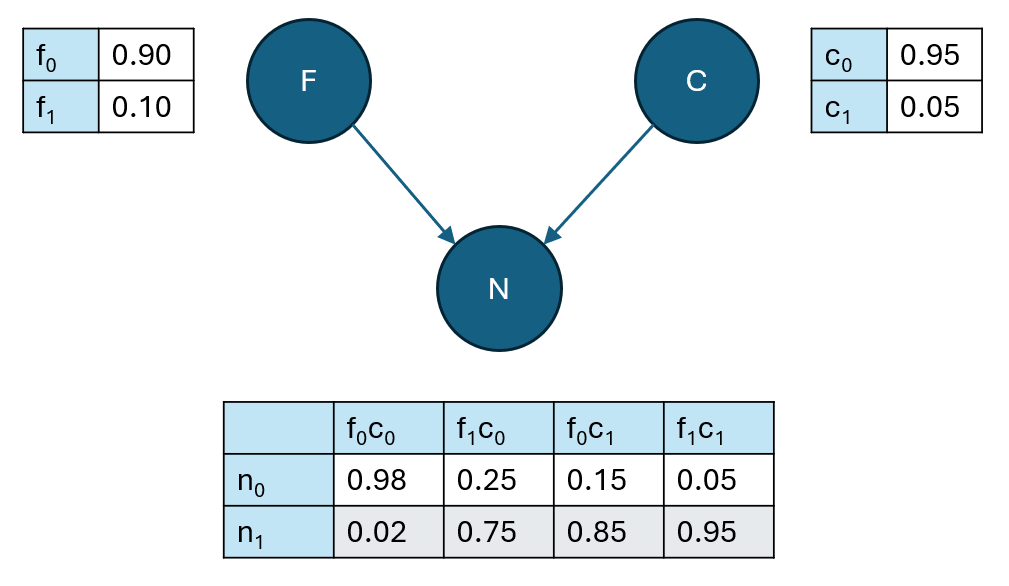

In [1]:
# paqueterías
from pgmpy.models import BayesianNetwork, DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD

In [2]:
# Arcos
AC_model = DiscreteBayesianNetwork(
    [("F", "N"), ("C", "N")]
)

# CPDs
cpd_F = TabularCPD(
    variable ='F',
    variable_card=2,
    values = [[0.9],[0.1]]
)

cpd_C = TabularCPD(
    variable ='C',
    variable_card=2,
    values = [[0.95],[0.05]]
)

cpd_N = TabularCPD(
    variable='N',
    variable_card=2,
    values=[
        [0.98,0.15,0.25,0.05],
        [0.02,0.85,0.75,0.95]
    ],
    evidence=['F', 'C'], 
    evidence_card=[2, 2] 
)

In [3]:
AC_model.add_cpds(cpd_F,cpd_C,cpd_N)

In [4]:
print(cpd_N)

+------+------+------+------+------+
| F    | F(0) | F(0) | F(1) | F(1) |
+------+------+------+------+------+
| C    | C(0) | C(1) | C(0) | C(1) |
+------+------+------+------+------+
| N(0) | 0.98 | 0.15 | 0.25 | 0.05 |
+------+------+------+------+------+
| N(1) | 0.02 | 0.85 | 0.75 | 0.95 |
+------+------+------+------+------+


2. Responde la consulta: el equipo no enfría →P(F=fuga | N=no enfría), de tres formas (ingenua, VariableElimination, y comparada con la base P(F=fuga)). Luego el técnico confirma que el compresor falló → P(F=fuga | N=no enfría, C=fallo). ¿Qué le pasa a la creencia de la fuga?

In [5]:
from pgmpy.inference import VariableElimination

c:\Users\chico\OneDrive\Documentos\Development\gitHub\modelos-graficos-probabilisticos\.venv\Lib\site-packages\pgmpy\estimators\__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in v1.3.0. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


2.1 Consulta $ P(f^1|n^1) $ usando fuerza bruta (forma ingenua)

In [6]:
# Obtenemos la distribución conjunta de la red

p_joint = (
    cpd_F.to_factor()
    * cpd_C.to_factor()
    * cpd_N.to_factor()
)
print(p_joint)

+------+------+------+--------------+
| F    | C    | N    |   phi(F,C,N) |
+======+======+======+==============+
| F(0) | C(0) | N(0) |       0.8379 |
+------+------+------+--------------+
| F(0) | C(0) | N(1) |       0.0171 |
+------+------+------+--------------+
| F(0) | C(1) | N(0) |       0.0068 |
+------+------+------+--------------+
| F(0) | C(1) | N(1) |       0.0383 |
+------+------+------+--------------+
| F(1) | C(0) | N(0) |       0.0238 |
+------+------+------+--------------+
| F(1) | C(0) | N(1) |       0.0713 |
+------+------+------+--------------+
| F(1) | C(1) | N(0) |       0.0003 |
+------+------+------+--------------+
| F(1) | C(1) | N(1) |       0.0048 |
+------+------+------+--------------+


$ P(f^1 | n^1) = \frac{P(f^1, n^1)}{P(n^1)} = \frac{\sum_{C} P(f^1, C, n^1)}{\sum_{F,C} P(F, C, n^1)} $

$ \sum_{C} P(f^1, C, n^1) $

In [7]:
p_mar_C = p_joint.marginalize(variables=['C'], inplace=False)
print(p_mar_C)

+------+------+------------+
| F    | N    |   phi(F,N) |
+======+======+============+
| F(0) | N(0) |     0.8447 |
+------+------+------------+
| F(0) | N(1) |     0.0554 |
+------+------+------------+
| F(1) | N(0) |     0.0240 |
+------+------+------------+
| F(1) | N(1) |     0.0760 |
+------+------+------------+


$ P(f^1,n^1) $

In [11]:
p_f1_n1 = p_mar_C.reduce([('F', 1), ('N', 1)], inplace=False)
print(p_f1_n1)

+---------+
|   phi() |
+=========+
|  0.0760 |
+---------+


$ \sum_{F,C} P(F, C, n^1) $

In [13]:
p_mar_FC = p_joint.marginalize(variables=['F','C'], inplace=False)
print(p_mar_FC)

+------+----------+
| N    |   phi(N) |
+======+==========+
| N(0) |   0.8687 |
+------+----------+
| N(1) |   0.1314 |
+------+----------+


$ P(n^1) $

In [15]:
p_n1 = p_mar_FC.reduce([('N', 1)], inplace=False)
print(p_n1)

+---------+
|   phi() |
+=========+
|  0.1314 |
+---------+


$ P(f^1 | n^1) = \frac{P(f^1, n^1)}{P(n^1)} $

In [23]:
n=p_mar_C.get_value(F=1, N=1)
d=p_mar_FC.get_value(N=1)

In [25]:
ingenua=n/d
print(ingenua)

0.5786067757898744


2.2 Consulta $ P(f^1|n^1) $ usando VariableElimination

In [12]:
# Razonamiento evidencial
inferencia = VariableElimination(AC_model)

# 2.1 P(F=Fuga | N=no enfría)
phi = inferencia.query(
    variables=['F'],
    evidence={'N': 1}
)
phi.values[1]

np.float64(0.5786067757898744)

2.3 Comparando $P(f^1|n^1) $, es decir, la probabilidad de fuga dado que no enfría, con la probabilidad base $ P(f^1) = 0.10 $ (fuga de refrigerante), podemos apreciar que $P(f^1|n^1) > P(f^1) $ ya que, en el lado izquierdo, tenemos la evidencia de que no enfría (lo que aumenta la probabilidad de que haya perdido refrigerante).

Como la consulta tiene la forma $P(causa|efecto)$ (se pregunta por la causa), esta inferencia es **evidencial**.

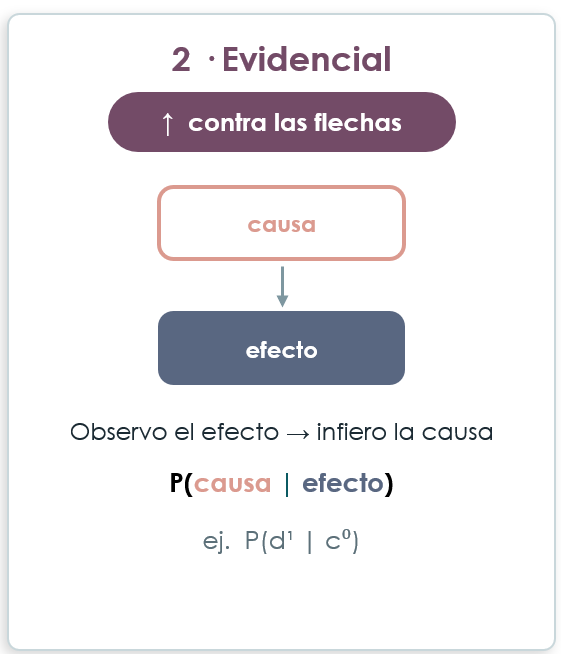

2.4 Luego el técnico confirma que el compresor falló → P(F=fuga | N=no enfría, C=falló). ¿Qué le pasa a la creencia de la fuga?

In [27]:
# Razonamiento intercausal
inferencia = VariableElimination(AC_model)

# 2.1 P(F=Fuga | N=no enfría, C=falló)
phi2 = inferencia.query(
    variables=['F'],
    evidence={'N': 1,'C': 1}
)
phi2.values[1]

np.float64(0.11046511627906977)

Al tener una nueva evidencia independiente (compresor falló), entonces la probabilidad de que la causa halla sido fuga de refrigerante disminuye, es decir $P(f^1|n^1) > P(f^1|n^1,c^1)$

Como la consulta pregunta por una de las causas independientes $f^1$ y como evidencia tenemos el efecto $n^1$ junto con la otra causa independiente $c^1$, entonce el tipo de razonamiento es **intercausal**.

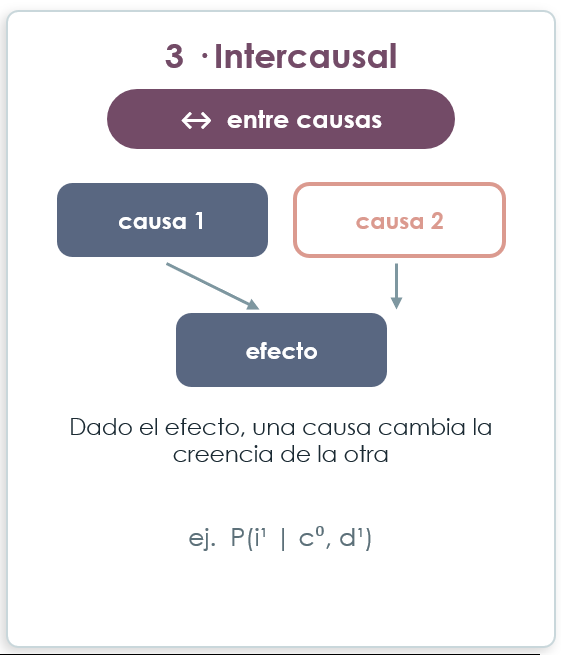